In [ ]:
import pandas as pd
df = pd.read_csv('../data/historical_prices.csv', skipinitialspace=True)
df.columns = df.columns.str.strip() # ubiraet probeli i znaki(/n,/t i t.d.) v strokah
df.head()

In [ ]:
df.dtypes

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')
df = df.set_index('Date') # datu delaem indexom
df.dtypes

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df['Close'].describe()

In [ ]:
df['Change'] = df['Close'] - df['Open']
df['Change'].describe()

In [ ]:
df['Return'] = df['Close'].pct_change()
df['Return'].describe()

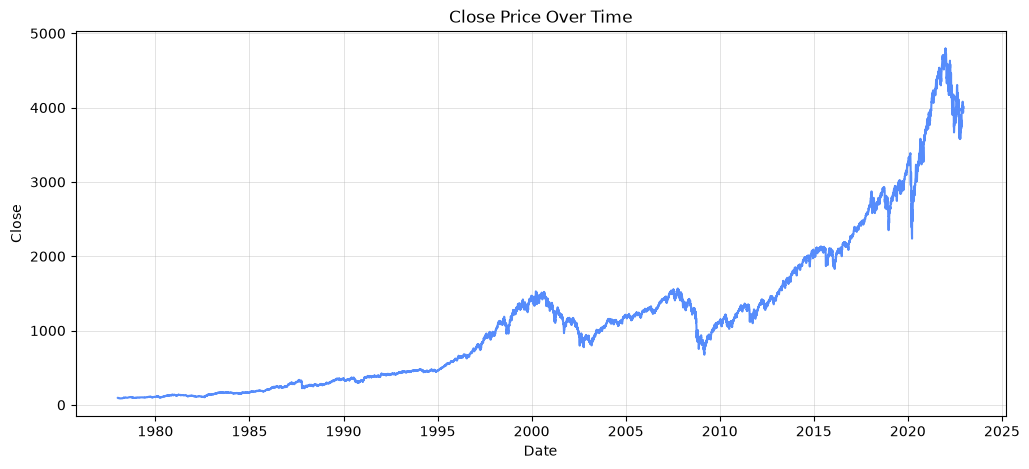

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Close'])
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Close Price Over Time')
plt.grid(True)
plt.show()

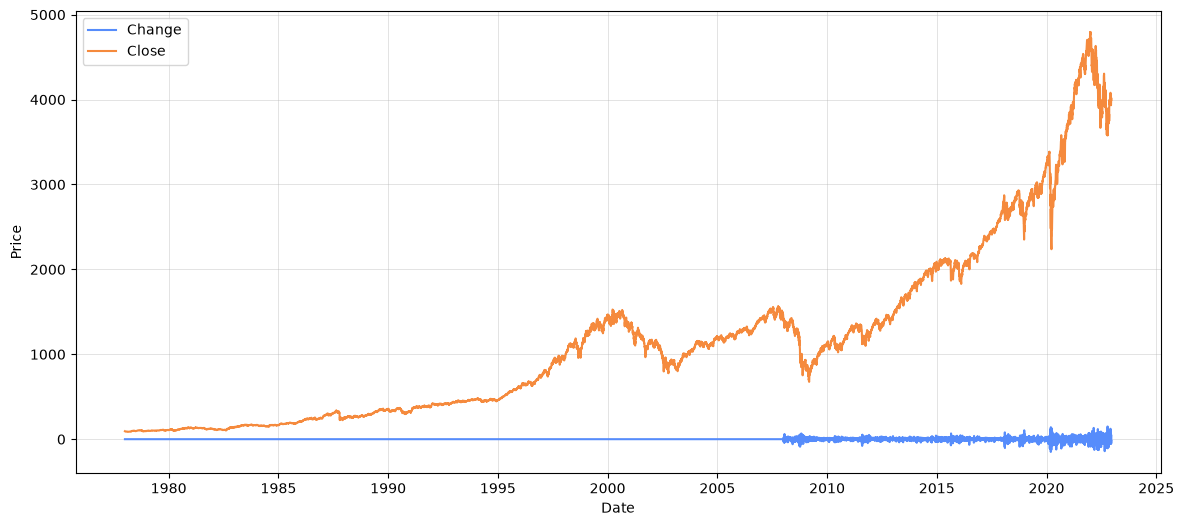

In [43]:
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Change'], label='Change')
plt.plot(df.index, df['Close'], label='Close')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

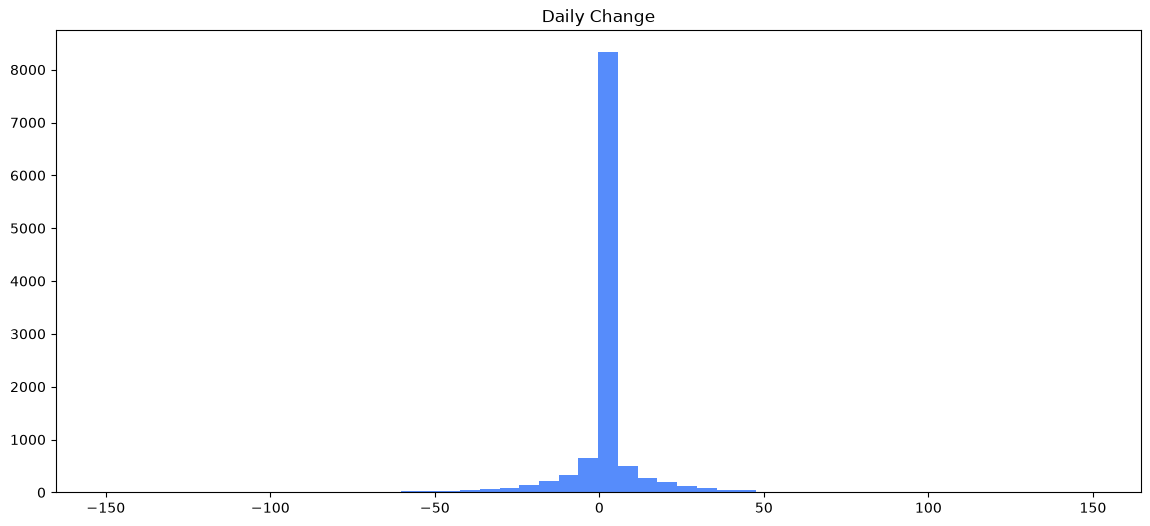

In [46]:
plt.figure(figsize=(14,6))
plt.hist(df['Change'], bins=50)
plt.title('Daily Change')
plt.show()

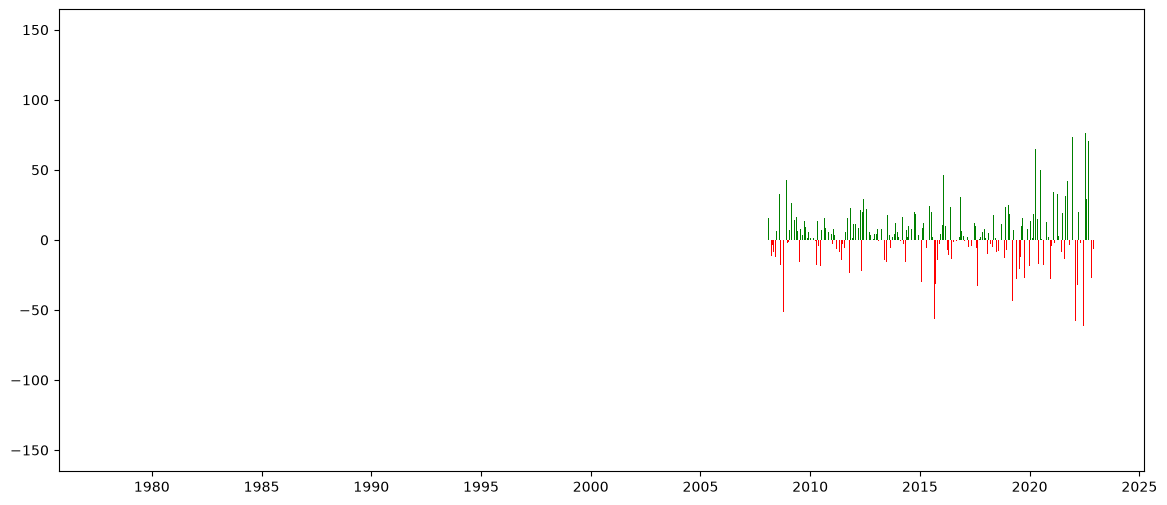

In [47]:
colors = ['green' if x > 0 else 'red' for x in df['Change']]
plt.figure(figsize=(14,6))
plt.bar(df.index, df['Change'], color=colors)
plt.show()

In [48]:
print(df['High'].max())
print(df['Low'].min())

4818.62
86.45


In [50]:
df['Close'].idxmax()

Timestamp('2022-01-03 00:00:00')

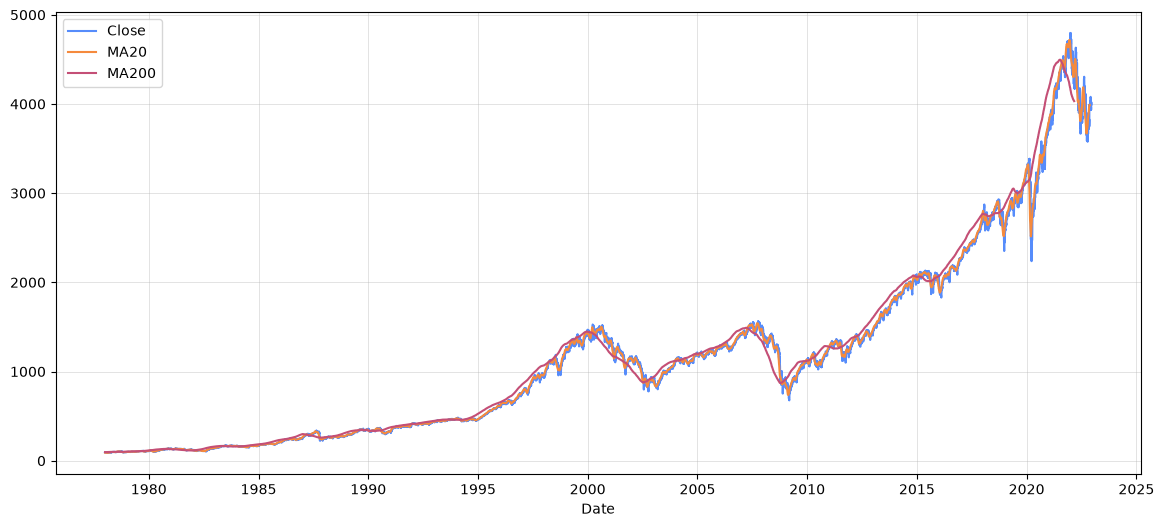

In [53]:
df['MA20'] = df['Close'].rolling(20).mean()
df['MA200'] = df['Close'].rolling(200).mean()
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'], label='Close')
plt.plot(df.index, df['MA20'], label='MA20')
plt.plot(df.index, df['MA200'], label='MA200')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()